# Customer Segmentation EDA

This notebook is the first step in a retail customer segmentation project using K-Means clustering. The focus here is exploratory data analysis (EDA): understanding the dataset, checking data quality, and looking for patterns that may matter for future clustering.

## Notebook goals
- Learn what the customer data contains
- Check whether the data is clean and reliable
- Explore relationships between customer features
- Prepare for later clustering work without performing it yet

## Section 1: Import Libraries

In this section, we import the core Python libraries that support data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 2: Load Dataset

In this section, we load the customer dataset using the helper function from the project source code.

In [2]:
from pathlib import Path
import sys

# Make sure the project root is available for imports
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_loader import load_customer_data

df = load_customer_data("customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


## Section 3: Dataset Overview

In this section, we examine the structure of the dataset.

In [3]:
print("Shape of the dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
df.dtypes

Shape of the dataset:
(1000, 5)

Column names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:


CustomerID                  int64
Gender                        str
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

## Section 4: Data Quality Check

In this section, we check for missing values, duplicated rows, and the number of unique values.

In [4]:
missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()
unique_values = df.nunique(dropna=False)

print("Missing values per column:")
print(missing_values)

print("\nNumber of duplicated rows:")
print(duplicate_rows)

print("\nUnique values per column:")
print(unique_values)

Missing values per column:
CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

Number of duplicated rows:
0

Unique values per column:
CustomerID                1000
Gender                       3
Age                         63
Annual Income (k$)         593
Spending Score (1-100)      85
dtype: int64


In [5]:
df["Gender"].value_counts()

Gender
F    522
M    475
Name: count, dtype: int64

## Section 5: Statistical Analysis

In this section, we examine basic descriptive statistics like, mean, median, std, min and max, to understand the overall behaviour of the dataset.

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


### Observation from Section 1 - 5. 

- The dataset contains 1000 customer records with 5 features.
- CustomerID is just unique identifier and will not be used in K-means clustering.
- A small number of missing values exist (<1% of observations) and needs to be handled in preprocessing.
- The dataset includes both demographic (Age, gender) and behavioral (Annual income, Spending score) features suitable for clustering.
- Gender classified as male and female, the unique value count counted NaN as another unique classification. 
- Based on age min and age max, there is no impossible data. 
- Numerical features such as income and spending score show sufficient variation for customer segmentation (age CV = 0.34, income CV = 0.5, spending CV = 0.47).

## Section 6: Feature Exploration

Exploring the main customer features visually.

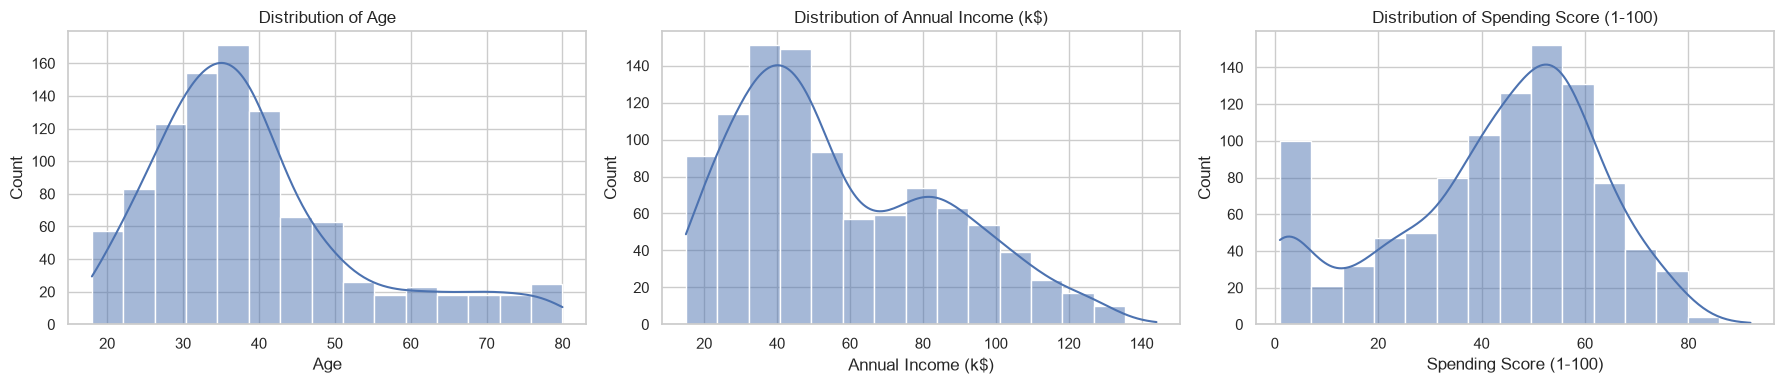

In [7]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, feature in zip(axes, features):
    sns.histplot(df[feature], bins=15, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### Graphic Interpretation

- Most of the data comes from young adults age range of (30 - 40)
- Annual Income graphic suggest there are 2 segmentations, those with medium low annual income and those with medium high annual income.
- Spending Score graphic also suggest 2 segmentations, those with very low spending score (range 1-7) and those with medium high spending score.

## Section 7: Customer Relationship Visualization

Visualizing the relationship between annual income and spending score.

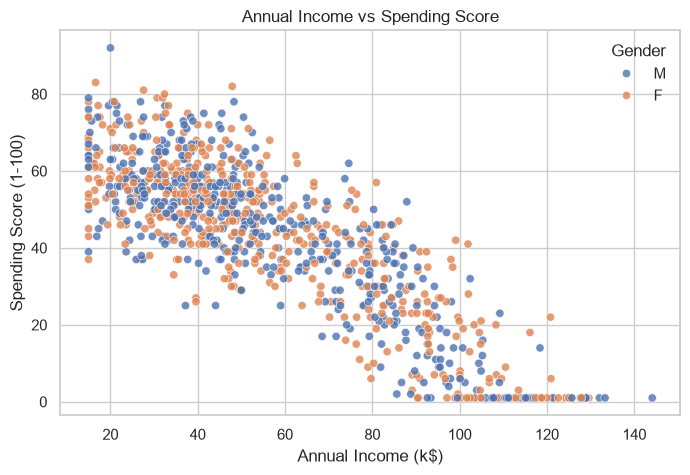

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    alpha=0.8
)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

### Data Analysis

- Very interesting data suggesting that high income not always high spend, and low income tends to spend more.
- Gender here seems mixed and does not shows any specific behavior.

## Section 8: Corelation Analysis 

Trying to see the corelation between features.


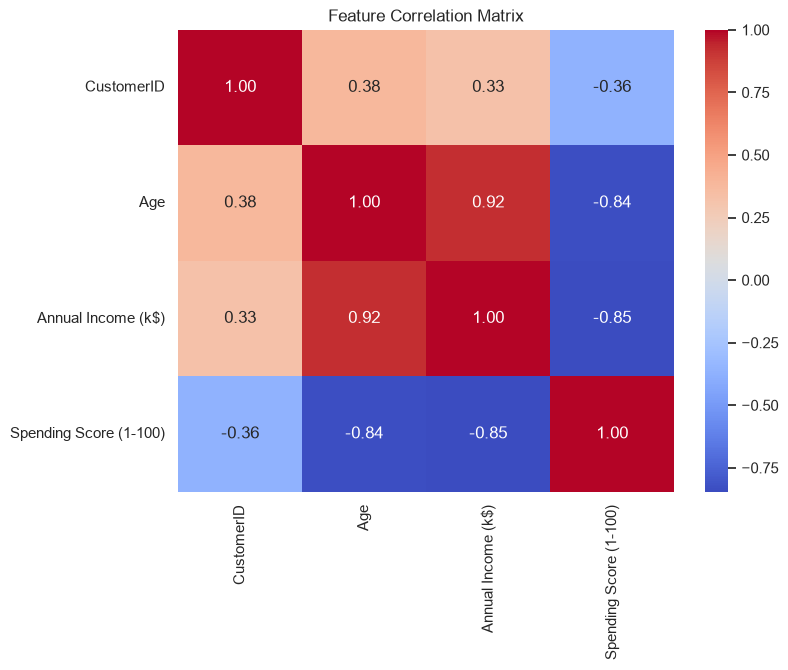

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

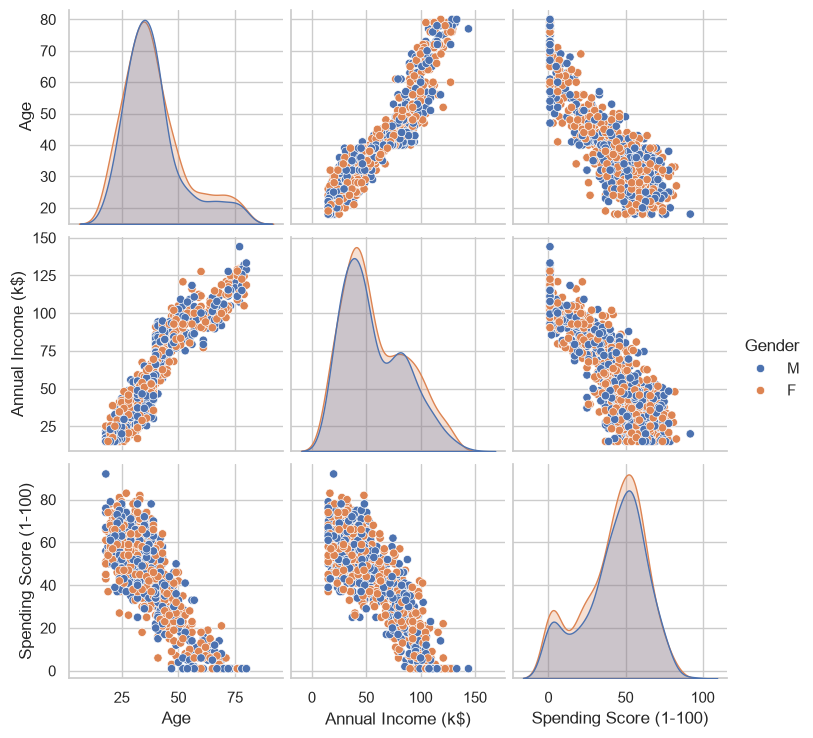

In [10]:
sns.pairplot(
    df,
    vars=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ],
    hue="Gender"
)

plt.show()

### Data Analysis

- Customer ID is not related so we just ignore it.
- Correlation analysis revealed strong correlation between Age and Annual Income (r=0.92). Since K-Means relies on distance calculations, retaining both variables could overweight the same underlying factor. Therefore, Age was excluded to avoid redundant information and maintain balanced feature contribution.

### Business Observations and Initial Hypothesis

- Observation:

Based on the Income vs Spending Score scatter plot, an initial hypothesis suggests the existence of three potential customer segments:
  - High engagement customers: Low income, high spending behavior
  - Standard customers: Medium income, medium spending behavior
  - High income low engagement customers: High income, low spending behavior

These observations serve as an initial business hypothesis and will be validated and refined after applying K-Means clustering.

- Strategy for high engagement customers:

Retention and affordability strategies could be considered, such as discounts, membership rewards, and bundle offers, to maintain high engagement while addressing potential price sensitivity.

- Strategy for standard customers:

Engagement enhancement strategies could be applied, including personalized recommendations, loyalty program upgrades, and cross-selling opportunities to increase customer value.

- Strategy for high-income low-engagement customers:

Re-engagement strategies could be explored through premium product recommendations, personalized marketing campaigns, and customer feedback surveys to understand barriers to purchase.